# Main Analysis

## We want to compare the performance of our models only on patients that do not have symptoms at baseline (non-dyskinetic patients at baseline)

NB. No info about dyskinesia at baseline is used during training.

First we train our ML classifiers on the entire training population to maximize information during training. Then, we test our models on the held-out test set, at this point we have a prediction for each patient of our test set, to analyze how our models behaves we compute performance metrics twice:

1. First, we use all predicted probabilities from all patients, knowing that the results are biased and "pumped" because of the presence of already active patients at baseline
2. Then, we exclude all dyskinetic patients at baseline and we compute again metrics using the predicted probabilities of non active patients at baseline. This second analysis is more realistic and can tell us how the considered models behave in a cohort of "unknown" patients in terms of baseline dsykinesia -> this is more clinically relevant.

Finally we can also directly train our models on non-dyskinetic patients at baselin, however this results in a loss of information that leads to a drop in performances.
- Also in this case we have results (stored in ../results/no_active_patients_at_bl/)


## Functions 

- add_run_id(): helper function that add a 'run_id' column to the raw results dataframe, a dataframe that contains the predicted probabilities af all patients present in the test set. Note that in this dataframe patients are repeated since we performa a nested cv. So at each iteration we have a slightly different test set but with possible overlapping patients across iterations.
-> the run_id column will be used to compute performance metrics across iterations, rather than doing a single average on all patients.

- get_per_run_metrics(): compute all performance metrics for all models and for all runs

- summarize_long_df(): summarize the output of get_per_run_metrics()

- plot_professional_calibration(): 

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, matthews_corrcoef, roc_auc_score
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score

def add_run_id(df, chunk_size):
    """
    Infers a run_id by taking floor(row_index / chunk_size).
    Adds a 'run_id' column and returns the new DataFrame.
    """
    df = df.reset_index(drop=True).copy()
    df['run_id'] = (np.arange(len(df)) // chunk_size)
    return df



def summarize_long_df_pivoted(long_df, models, analyses):
    """
    Returns a summary DataFrame with analyses pivoted into columns.
    
    Parameters
    ----------
    long_df : pd.DataFrame
        Must have columns ['analysis', 'model', 'group', 'Metric', 'Score'].
    models : list of str
        The classifiers to process.
    analyses : list of str
        The analyses to include.

    Returns
    -------
    stats_df : pd.DataFrame
        - Index: (model, Metric)
        - Columns: MultiIndex with top level as 'analysis' and 
                   second level as the summary type 
                   ('all_summary', 'subset_summary', 'mean_diff').
    """
    # 1. Filter the DataFrame
    df_filtered = long_df[
        long_df['model'].isin(models) & 
        long_df['analysis'].isin(analyses)
    ].copy()

    # 2. Group and aggregate scores
    stats = (
        df_filtered
        .groupby(['analysis', 'model', 'Metric', 'group'])['Score']
        .agg(['mean', 'std'])
        .unstack(level='group') # Unstack 'group' to get 'All'/'Subset' columns
    )
    
    # 3. Flatten the column MultiIndex for easier access
    stats.columns = ['_'.join(col).lower() for col in stats.columns]

    # 4. Create the summary and difference columns
    stats['all_summary'] = stats.apply(
        lambda row: f"{row['mean_all']:.2f} ± {row['std_all']:.2f}", axis=1
    )
    stats['subset_dysk_summary'] = stats.apply(
        lambda row: f"{row['mean_subset_dysk']:.2f} ± {row['std_subset_dysk']:.2f}", axis=1
    )

    
    # 5. Select only the final columns we want to display
    final_summary_cols = ['all_summary', 'subset_dysk_summary', 'mean_all', 'mean_subset_dysk', 'std_all', 
                          'std_subset_dysk']

    # 6. Unstack 'analysis' to pivot it into columns and clean up
    pivoted_df = stats[final_summary_cols].unstack(level='analysis')
    
    # 7. Swap the levels of the column index to put analysis on top
    pivoted_df.columns = pivoted_df.columns.swaplevel(0, 1)
    
    # 8. Sort the columns by the top level (analysis name) for a clean layout
    pivoted_df.sort_index(axis=1, inplace=True)
    
    return pivoted_df


def get_per_run_metrics(df, threshold=0.5):
    df = df.dropna(subset=['real y','prob y=1']).copy()
    df['pred y'] = (df['prob y=1'] > threshold).astype(int)
    records = []
    for (analysis, model, run_id, group), grp in df.groupby(['analysis', 'model','run_id','group']):
        records.append({
            'analysis': analysis,
            'model': model,
            'run_id': run_id,
            'group': group,
            'MCC': matthews_corrcoef(grp['real y'], grp['pred y']),
            'AUC': roc_auc_score(grp['real y'], grp['prob y=1']),
            'F1': f1_score(grp['real y'], grp['pred y']),
            'Sensitivity': np.sum((grp['real y'] == 1) & (grp['pred y'] == 1)) / np.sum(grp['real y'] == 1) if np.sum(grp['real y'] == 1) > 0 else np.nan,
            'Specificity': np.sum((grp['real y'] == 0) & (grp['pred y'] == 0)) / np.sum(grp['real y'] == 0) if np.sum(grp['real y'] == 0) > 0 else np.nan,
            'PPV': precision_score(grp['real y'], grp['pred y'], zero_division=np.nan),
            'NPV': precision_score(grp['real y'], grp['pred y'], pos_label=0, zero_division=np.nan)
        })
    return pd.DataFrame(records)


def load_and_process_results(analysis_name, base_path, model, x_neuro_df, subset_pids_dysk):
    """Loads, processes, and prepares data for a single model run."""
    try:
        # Construct the full path
        path = base_path.format(outcome=OUTCOME)
        file_path = f'{path}{model}/raw_results.csv'
        df_raw = pd.read_csv(file_path)

        # Load and perform initial processing
        if analysis_name == 'no_active_patients_at_bl_drop':
            df_raw['PatientID'] = subset_pids_dysk.loc[df_raw['idx'], 'PatientID'].values
        else:
            df_raw['PatientID'] = x_neuro_df.loc[df_raw['idx'], 'PatientID'].values

        chunk_size = len(df_raw) // 30  # n. of external iterations..
        df_raw = add_run_id(df_raw, chunk_size=chunk_size) 
        
        # Add metadata columns
        df_raw['analysis'] = analysis_name
        df_raw['model'] = model
        
        # Create the 'All' and 'Subset' records from the single loaded DataFrame
        df_all = df_raw.copy()
        df_all['group'] = 'All'

        df_sub_dysk = df_raw[df_raw['PatientID'].isin(subset_pids_dysk['PatientID'])].copy()
        df_sub_dysk['group'] = 'Subset_Dysk'

        return df_all, df_sub_dysk

    except FileNotFoundError:
        print(f"  - WARNING: File not found, skipping -> {file_path}")
        return None, None




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

def plot_full_summary(summary_df, metrics=None, palette=None):
    """
    Draws a comprehensive grouped bar plot from a summary DataFrame that has a 
    MultiIndex on its columns (level 0: analysis, level 1: metric type).

    Creates one plot per metric, showing models on the x-axis and all 
    analysis/group combinations as the grouped bars.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Indexed by (model, Metric), with a MultiIndex on columns.
    metrics : list of str, optional
        Which metrics to plot (default: all metrics in summary_df).
    palette : list, optional
        A sequence of colors to cycle through for the bars.
    """
    if palette is None:
        # A palette with enough distinct, colorblind-friendly colors
        palette = plt.get_cmap('tab20').colors
    
    if metrics is None:
        metrics = summary_df.index.get_level_values('Metric').unique()

    for metric in metrics:
        # Select the data for the current metric
        dfm = summary_df.xs(metric, level='Metric')
        models = dfm.index.tolist()
        
        # 1. Dynamically find all 'mean' columns to determine the groups to plot
        mean_cols = sorted([col for col in dfm.columns if 'mean' in col[1]])
        if not mean_cols:
            print(f"Skipping '{metric}': No 'mean_*' columns found.")
            continue
        
        n_groups = len(mean_cols)
        x = np.arange(len(models))
        
        # 2. Dynamically calculate bar positions to keep them centered
        total_bar_width = 0.9
        width = total_bar_width / n_groups
        start_offset = -total_bar_width / 2 + width / 2

        # --- Plotting ---
        fig, ax = plt.subplots(figsize=(16, 7))
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.set_axisbelow(True)

        # 3. Loop through every discovered group and draw its bar
        for i, mean_col_tuple in enumerate(mean_cols):
            # Construct the corresponding std deviation column name
            std_col_tuple = (mean_col_tuple[0], mean_col_tuple[1].replace('mean', 'std'))
            std_values = dfm.get(std_col_tuple)
            
            position = x + start_offset + i * width
            
            # Create a clean, readable label from the column tuple
            analysis_name = mean_col_tuple[0].replace('_', ' ').title()
            group_name = mean_col_tuple[1].replace('mean_', '').title()
            label = f"{analysis_name} ({group_name})"
            
            ax.bar(
                position, 
                dfm[mean_col_tuple], 
                width,
                yerr=std_values, 
                capsize=2,
                label=label,
                color=palette[i % len(palette)]
            )

        # --- Aesthetics ---
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=0, fontsize=12)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('Score', fontsize=14)
        ax.set_title(f'{metric.upper()} Mean Score by Model and Analysis', fontsize=16, pad=20)
        ax.legend(frameon=True, fontsize=10, title='Analysis & Group', bbox_to_anchor=(1.01, 1), loc='upper left')

        plt.tight_layout(rect=[0, 0, 0.82, 1]) # Adjust layout for the legend
        plt.show()

In [3]:
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay
import matplotlib.gridspec as gridspec
import numpy as np

def plot_professional_calibration(
    y_true, 
    probs_raw, 
    probs_cal, 
    raw_metrics, 
    cal_metrics, 
    save_path=None
):
    """
    Generates a single publication-quality calibration plot with a metrics table.
    
    Parameters:
    - raw_metrics: Dict containing tuples of (mean, std) for 'slope', 'intercept', 'brier'
    - cal_metrics: Dict containing tuples of (mean, std) for 'slope', 'intercept', 'brier'
      Example: raw_metrics = {'slope': (1.29, 0.53), 'intercept': (0.02, 0.1), ...}
    """
    
    # 1. Setup Layout (3 rows for curve, 1 row for histograms)
    fig = plt.figure(figsize=(10, 10))
    gs = gridspec.GridSpec(4, 2, height_ratios=[3, 3, 3, 1.5])
    
    # Main Plot (Occupies top 3/4 of the figure)
    ax_main = plt.subplot(gs[:3, :])
    
    # Histograms (Occupies bottom 1/4, split left/right)
    ax_hist_raw = plt.subplot(gs[3, 0])
    ax_hist_cal = plt.subplot(gs[3, 1])

    # --------------------------------------------------------------------------
    # A. MAIN CALIBRATION CURVES
    # --------------------------------------------------------------------------
    
    # Plot 1: Raw Model (Orange)
    CalibrationDisplay.from_predictions(
        y_true, 
        probs_raw, 
        n_bins=10, 
        name="Raw Model",
        ax=ax_main,
        color="darkorange",
        strategy='quantile', # Use quantile bins for better distribution
        marker='s', # square
        linestyle='--'
    )
    
    # Plot 2: Calibrated Model (Blue)
    CalibrationDisplay.from_predictions(
        y_true, 
        probs_cal, 
        n_bins=10, 
        name="Calibrated Model",
        ax=ax_main,
        strategy='quantile', # Use quantile bins for better distribution

        color="navy",
        marker='o' # circle
    )

    # Customizing Main Plot
    ax_main.set_title("Calibration Improvement: Raw vs. Calibrated", fontsize=14, pad=10)
    ax_main.set_ylabel("Observed Fraction (True Risk)", fontsize=12)
    ax_main.set_xlabel("Mean Predicted Probability", fontsize=12)
    ax_main.grid(True, linestyle=':', alpha=0.6)
    ax_main.legend(loc='upper left', fontsize=11)

    # --------------------------------------------------------------------------
    # B. THE "SCORECARD" (Adding Metrics Text Box)
    # --------------------------------------------------------------------------
    # Helper to format string: "1.29 ± 0.53"
    def fmt(m, key):
        mean, std = m[key]
        return f"{mean:.2f} ± {std:.2f}"

    stats_text = (
        r"$\bf{Raw\ Model}$" + "\n"
        f"Slope: {fmt(raw_metrics, 'slope')}\n"
        f"Intercept: {fmt(raw_metrics, 'intercept')}\n"
        f"Brier: {fmt(raw_metrics, 'brier')}\n\n"
        r"$\bf{Calibrated\ Model}$" + "\n"
        f"Slope: {fmt(cal_metrics, 'slope')}\n"
        f"Intercept: {fmt(cal_metrics, 'intercept')}\n"
        f"Brier: {fmt(cal_metrics, 'brier')}"
    )

    # Place text box in bottom right
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    ax_main.text(
        0.95, 0.05, 
        stats_text, 
        transform=ax_main.transAxes, 
        fontsize=11,
        verticalalignment='bottom', 
        horizontalalignment='right', 
        bbox=props
    )

    # --------------------------------------------------------------------------
    # C. HISTOGRAMS (Distribution of Predictions)
    # --------------------------------------------------------------------------
    
    # Raw Hist
    ax_hist_raw.hist(probs_raw, range=(0, 1), bins=10, color="darkorange", alpha=0.7, edgecolor='white')
    ax_hist_raw.set_title("Raw Distribution", fontsize=10)
    ax_hist_raw.set_xlabel("Probability", fontsize=10)
    ax_hist_raw.set_yticks([]) # Hide y-axis numbers to save space
    ax_hist_raw.spines['top'].set_visible(False)
    ax_hist_raw.spines['right'].set_visible(False)
    ax_hist_raw.spines['left'].set_visible(False)

    # Calibrated Hist
    ax_hist_cal.hist(probs_cal, range=(0, 1), bins=10, color="navy", alpha=0.7, edgecolor='white')
    ax_hist_cal.set_title("Calibrated Distribution", fontsize=10)
    ax_hist_cal.set_xlabel("Probability", fontsize=10)
    ax_hist_cal.set_yticks([])
    ax_hist_cal.spines['top'].set_visible(False)
    ax_hist_cal.spines['right'].set_visible(False)
    ax_hist_cal.spines['left'].set_visible(False)

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# MAIN

In [4]:
''' MAIN SCRIPT '''
import pandas as pd
import numpy as np


# Use a dictionary to safely link analysis names to their directories
ANALYSIS_CONFIG = {
    'no_bl_info_for_training': '../results_w_calibration_v4_manuscript/no_bl_info_for_training/{outcome}/',
    'no_active_patients_at_bl_drop': '../results_w_calibration_v4_manuscript/no_active_patients_at_bl_drop/{outcome}/',
    'no_bl_info_for_training_random_drop': '../results_w_calibration_v4_manuscript/no_bl_info_for_training_random_drop/{outcome}/'
}
MODELS = ['randomforestclassifier', 'logisticregression', 'xgbclassifier', 'extratreesclassifier', 'svc', 'voting', 'stacking']
OUTCOME = 'FutureDyskinesia'
INPUT_TYPE = 'neuro_dyskinesia'



# --- Main script execution ---
print("Loading base data...")
x_neuro = pd.read_csv('../data/X_neuroart_v4.csv')
idxtokeep_dysk = pd.read_csv(f'../data/clusters/{INPUT_TYPE}.csv')
idxtokeep_all = pd.read_csv(f'../data/clusters/neuro_fluctuations.csv')


all_dfs_to_concat = []

# iterate through all experiments
for analysis, path_template in ANALYSIS_CONFIG.items():
    print(f"Processing Analysis: {analysis}...")
    for model in MODELS:
        print(f"  - Model: {model}")
        df_all, df_sub_dysk = load_and_process_results(analysis, path_template, model, x_neuro, idxtokeep_dysk) 
        # Append valid DataFrames to our list
        if df_all is not None:
            all_dfs_to_concat.append(df_all)
            all_dfs_to_concat.append(df_sub_dysk)

# Final Combination and Transformation ---
print("\nCombining all results and calculating metrics...")
if all_dfs_to_concat:
    combined = pd.concat(all_dfs_to_concat, ignore_index=True)
    
    # Calculate per-run metrics (assumed external function)
    per_run = get_per_run_metrics(combined, threshold=0.5) 
    
    # Melt into the final long format for plotting
    long_df = per_run.melt(
        id_vars=['analysis', 'model', 'group', 'run_id'],
        value_vars=['MCC', 'AUC', 'F1', 'Sensitivity', 'Specificity', 'PPV', 'NPV'],
        var_name='Metric', 
        value_name='Score'
    )
    print("\nSuccessfully created long_df.")
    # display(long_df.head()) 
else:
    print("\nNo data was loaded. `long_df` was not created.")

Loading base data...
Processing Analysis: no_bl_info_for_training...
  - Model: randomforestclassifier
  - Model: logisticregression
  - Model: xgbclassifier
  - Model: extratreesclassifier
  - Model: svc
  - Model: voting
  - Model: stacking
Processing Analysis: no_active_patients_at_bl_drop...
  - Model: randomforestclassifier
  - Model: logisticregression
  - Model: xgbclassifier
  - Model: extratreesclassifier
  - Model: svc
  - Model: voting
  - Model: stacking
Processing Analysis: no_bl_info_for_training_random_drop...
  - Model: randomforestclassifier
  - Model: logisticregression
  - Model: xgbclassifier
  - Model: extratreesclassifier
  - Model: svc
  - Model: voting
  - Model: stacking

Combining all results and calculating metrics...



Successfully created long_df.


In [5]:
long_df[long_df['analysis'] == 'no_bl_info_for_training_random_drop']

,analysis,model,group,run_id,Metric,Score
840,no_bl_info_for_training_random_drop,extratreesclassifier,All,0,MCC,0.507046
841,no_bl_info_for_training_random_drop,extratreesclassifier,Subset_Dysk,0,MCC,0.440688
842,no_bl_info_for_training_random_drop,extratreesclassifier,All,1,MCC,0.402430
843,no_bl_info_for_training_random_drop,extratreesclassifier,Subset_Dysk,1,MCC,0.154401
844,no_bl_info_for_training_random_drop,extratreesclassifier,All,2,MCC,0.133171
...,...,...,...,...,...,...
8815,no_bl_info_for_training_random_drop,xgbclassifier,Subset_Dysk,27,NPV,0.740741
8816,no_bl_info_for_training_random_drop,xgbclassifier,All,28,NPV,0.666667
8817,no_bl_info_for_training_random_drop,xgbclassifier,Subset_Dysk,28,NPV,0.714286
8818,no_bl_info_for_training_random_drop,xgbclassifier,All,29,NPV,0.766667


In [6]:
summary = summarize_long_df_pivoted(long_df, models=MODELS, analyses=ANALYSIS_CONFIG.keys())

In [7]:
summary

analysis                           no_active_patients_at_bl_drop            \
                                                     all_summary  mean_all   
model                  Metric                                                
extratreesclassifier   AUC                           0.67 ± 0.08  0.666325   
                       F1                            0.11 ± 0.12  0.108392   
                       MCC                           0.03 ± 0.15  0.034027   
                       NPV                           0.70 ± 0.02  0.702322   
                       PPV                           0.38 ± 0.37  0.384821   
                       Sensitivity                   0.07 ± 0.09  0.071795   
                       Specificity                   0.95 ± 0.05  0.947778   
logisticregression     AUC                           0.69 ± 0.07  0.691197   
                       F1                            0.21 ± 0.12  0.214926   
                       MCC                           0.17 ± 0.15  0.171346   
                       NPV                           0.72 ± 0.02  0.719278   
                       PPV                           0.65 ± 0.29  0.646605   
                       Sensitivity                   0.14 ± 0.08  0.138462   
                       Specificity                   0.96 ± 0.05  0.955556   
randomforestclassifier AUC                           0.70 ± 0.07  0.701795   
                       F1                            0.28 ± 0.14  0.282561   
                       MCC                           0.14 ± 0.16  0.143894   
                       NPV                           0.73 ± 0.03  0.725176   
                       PPV                           0.47 ± 0.23  0.469045   
                       Sensitivity                   0.22 ± 0.11  0.215385   
                       Specificity                   0.89 ± 0.07  0.894444   
stacking               AUC                           0.69 ± 0.06  0.693547   
                       F1                            0.23 ± 0.14  0.229774   
                       MCC                           0.12 ± 0.14  0.121464   
                       NPV                           0.72 ± 0.03  0.719027   
                       PPV                           0.47 ± 0.19  0.473663   
                       Sensitivity                   0.17 ± 0.12  0.166667   
                       Specificity                   0.92 ± 0.06  0.920000   
svc                    AUC                           0.67 ± 0.08  0.670897   
                       F1                            0.19 ± 0.14  0.187239   
                       MCC                           0.14 ± 0.17  0.139983   
                       NPV                           0.72 ± 0.02  0.715798   
                       PPV                           0.59 ± 0.36  0.591461   
                       Sensitivity                   0.12 ± 0.10  0.123077   
                       Specificity                   0.95 ± 0.05  0.954444   
voting                 AUC                           0.68 ± 0.08  0.684957   
                       F1                            0.25 ± 0.14  0.245930   
                       MCC                           0.13 ± 0.16  0.134550   
                       NPV                           0.72 ± 0.03  0.720318   
                       PPV                           0.50 ± 0.25  0.496797   
                       Sensitivity                   0.18 ± 0.11  0.179487   
                       Specificity                   0.91 ± 0.07  0.913333   
xgbclassifier          AUC                           0.66 ± 0.07  0.658205   
                       F1                            0.13 ± 0.11  0.128953   
                       MCC                           0.02 ± 0.11  0.024919   
                       NPV                           0.70 ± 0.01  0.701134   
                       PPV                           0.36 ± 0.26  0.357711   
                       Sensitivity                   0.09 ± 0.09  0.092308   
                      

In [8]:

# Export the summary DataFrame to CSV without flattening the MultiIndex
# Use UTF-8 encoding to handle non-ASCII characters
summary[[   
        #('bl_info_for_training', 'all_summary'),
		#('bl_info_for_training', 'subset_dysk_summary'),
		('no_bl_info_for_training', 'all_summary'),
		('no_bl_info_for_training', 'subset_dysk_summary'),
		('no_active_patients_at_bl_drop', 'all_summary'),
		('no_bl_info_for_training_random_drop', 'all_summary'),
		('no_bl_info_for_training_random_drop', 'subset_dysk_summary')
		]].to_csv('model_summary_dyskinesia_calibration.csv', encoding='utf-8')


In [9]:
summary[[   
      #  ('bl_info_for_training', 'all_summary'),
		#('bl_info_for_training', 'subset_dysk_summary'),
        #('bl_info_for_training', 'subset_dysk_mf_summary'),
		('no_bl_info_for_training', 'all_summary'),
		('no_bl_info_for_training', 'subset_dysk_summary'),
       # ('no_bl_info_for_training', 'subset_dysk_mf_summary'),
		('no_active_patients_at_bl_drop', 'all_summary'),
		('no_bl_info_for_training_random_drop', 'all_summary'),
		('no_bl_info_for_training_random_drop', 'subset_dysk_summary')
		]]

analysis                           no_bl_info_for_training  \
                                               all_summary   
model                  Metric                                
extratreesclassifier   AUC                     0.77 ± 0.06   
                       F1                      0.59 ± 0.07   
                       MCC                     0.42 ± 0.11   
                       NPV                     0.74 ± 0.03   
                       PPV                     0.72 ± 0.11   
                       Sensitivity             0.51 ± 0.08   
                       Specificity             0.87 ± 0.07   
logisticregression     AUC                     0.78 ± 0.06   
                       F1                      0.57 ± 0.08   
                       MCC                     0.41 ± 0.11   
                       NPV                     0.74 ± 0.04   
                       PPV                     0.72 ± 0.12   
                       Sensitivity             0.48 ± 0.10   
                       Specificity             0.88 ± 0.07   
randomforestclassifier AUC                     0.80 ± 0.06   
                       F1                      0.62 ± 0.07   
                       MCC                     0.43 ± 0.11   
                       NPV                     0.77 ± 0.04   
                       PPV                     0.68 ± 0.10   
                       Sensitivity             0.59 ± 0.09   
                       Specificity             0.82 ± 0.08   
stacking               AUC                     0.79 ± 0.06   
                       F1                      0.62 ± 0.07   
                       MCC                     0.42 ± 0.12   
                       NPV                     0.77 ± 0.04   
                       PPV                     0.67 ± 0.11   
                       Sensitivity             0.59 ± 0.09   
                       Specificity             0.82 ± 0.08   
svc                    AUC                     0.79 ± 0.06   
                       F1                      0.61 ± 0.07   
                       MCC                     0.44 ± 0.12   
                       NPV                     0.75 ± 0.04   
                       PPV                     0.73 ± 0.12   
                       Sensitivity             0.54 ± 0.09   
                       Specificity             0.87 ± 0.07   
voting                 AUC                     0.80 ± 0.06   
                       F1                      0.63 ± 0.06   
                       MCC                     0.43 ± 0.10   
                       NPV                     0.77 ± 0.04   
                       PPV                     0.68 ± 0.10   
                       Sensitivity             0.59 ± 0.09   
                       Specificity             0.82 ± 0.08   
xgbclassifier          AUC                     0.77 ± 0.06   
                       F1                      0.60 ± 0.08   
                       MCC                     0.39 ± 0.13   
                       NPV                     0.75 ± 0.04   
                       PPV                     0.65 ± 0.11   
                       Sensitivity             0.57 ± 0.09   
                       Specificity             0.81 ± 0.08   

analysis                                                \
                                   subset_dysk_summary   
model                  Metric                            
extratreesclassifier   AUC                 0.70 ± 0.08   
                       F1                  0.40 ± 0.10   
                       MCC                 0.24 ± 0.14   
                       NPV                 0.77 ± 0.03   
                       PPV                 0.53 ± 0.15   
                       Sensitivity         0.33 ± 0.10   
                       Specificity         0.87 ± 0.07   
logisticregression     AUC                 0.70 ± 0.07   
                       F1                  0.39 ± 0.11   
                       MCC                 0.25 ± 0.13   
                     

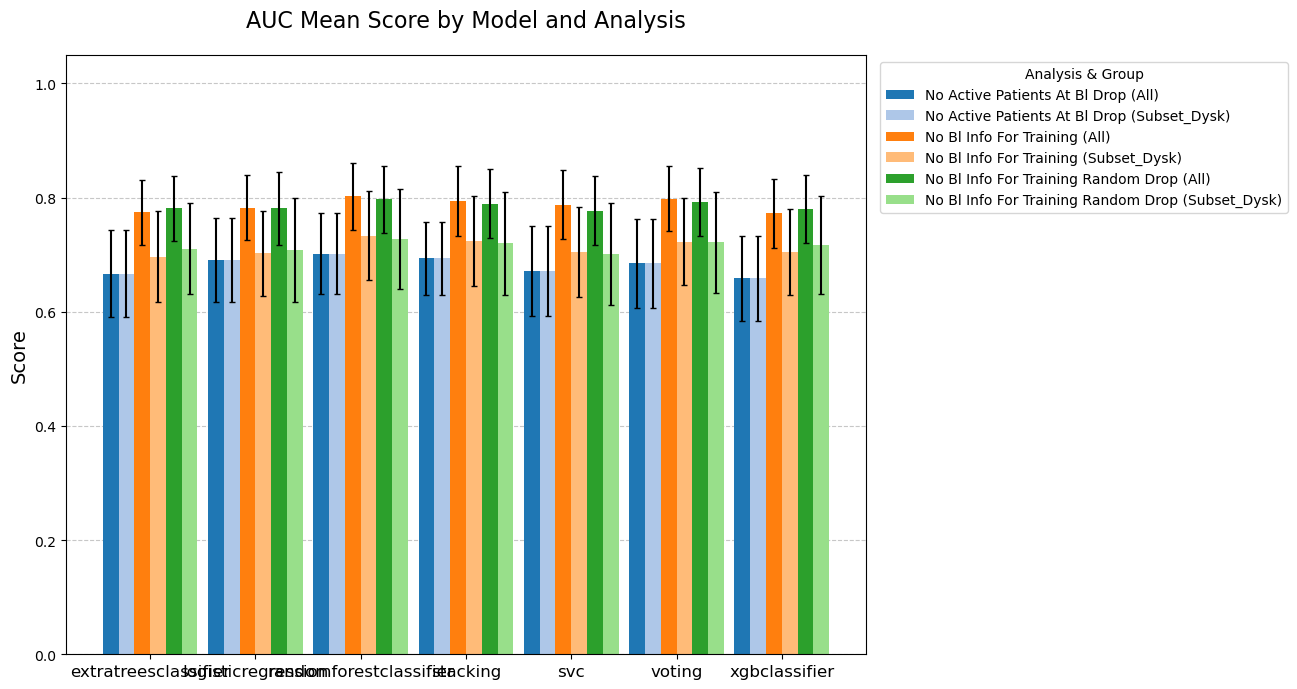

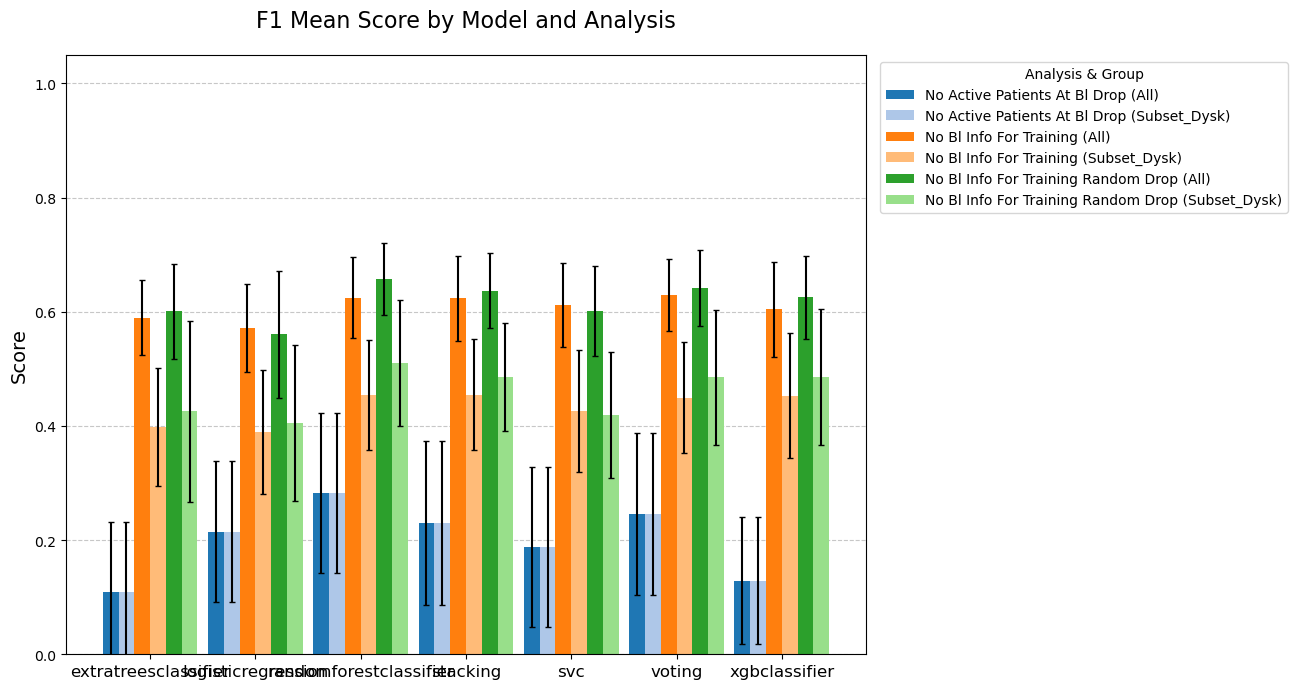

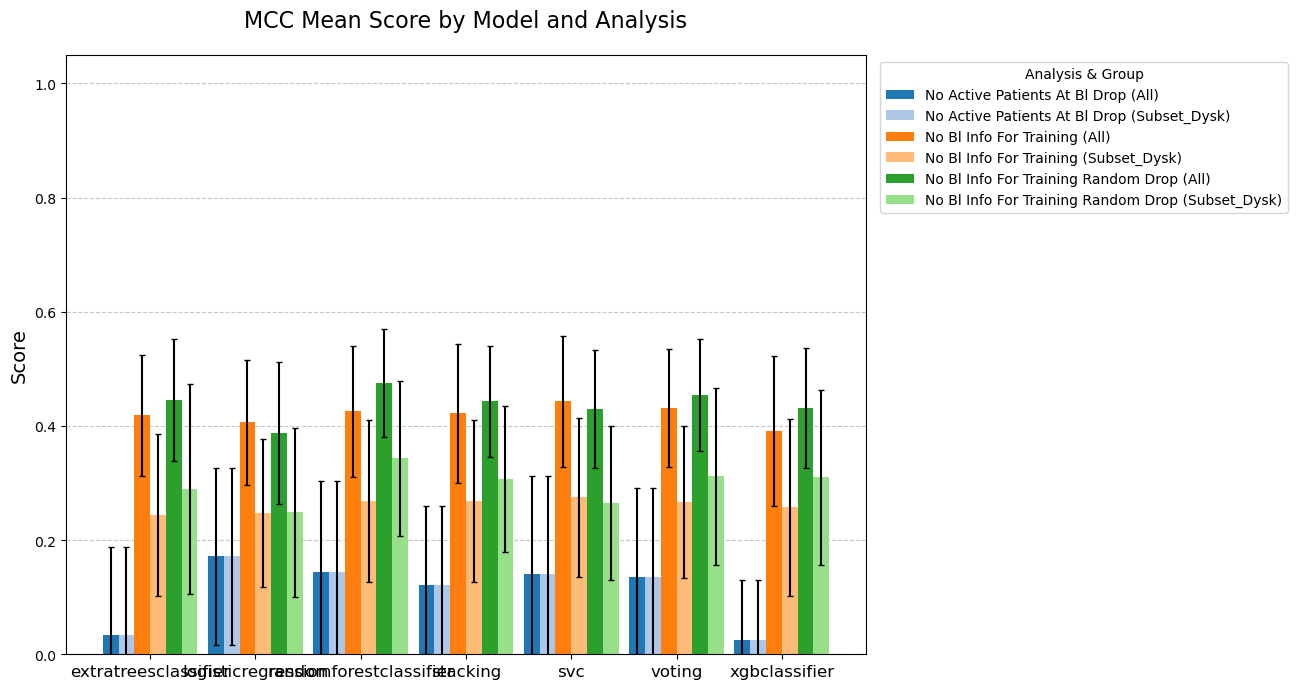

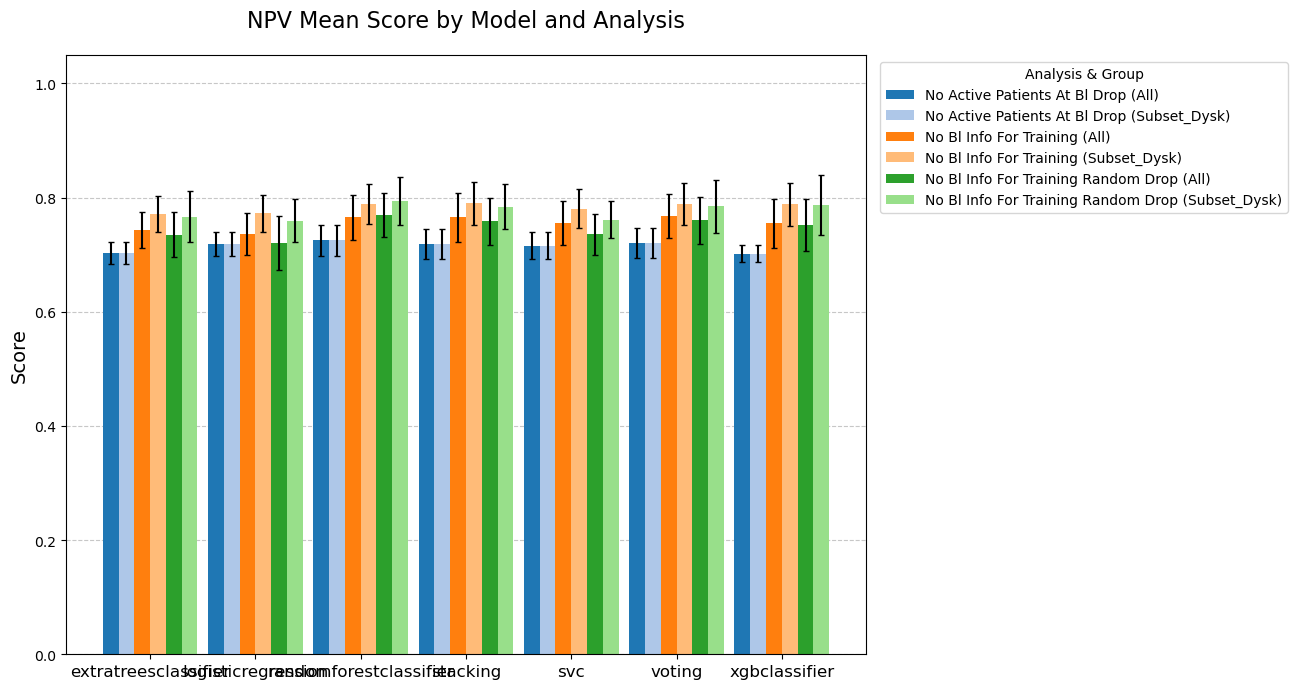

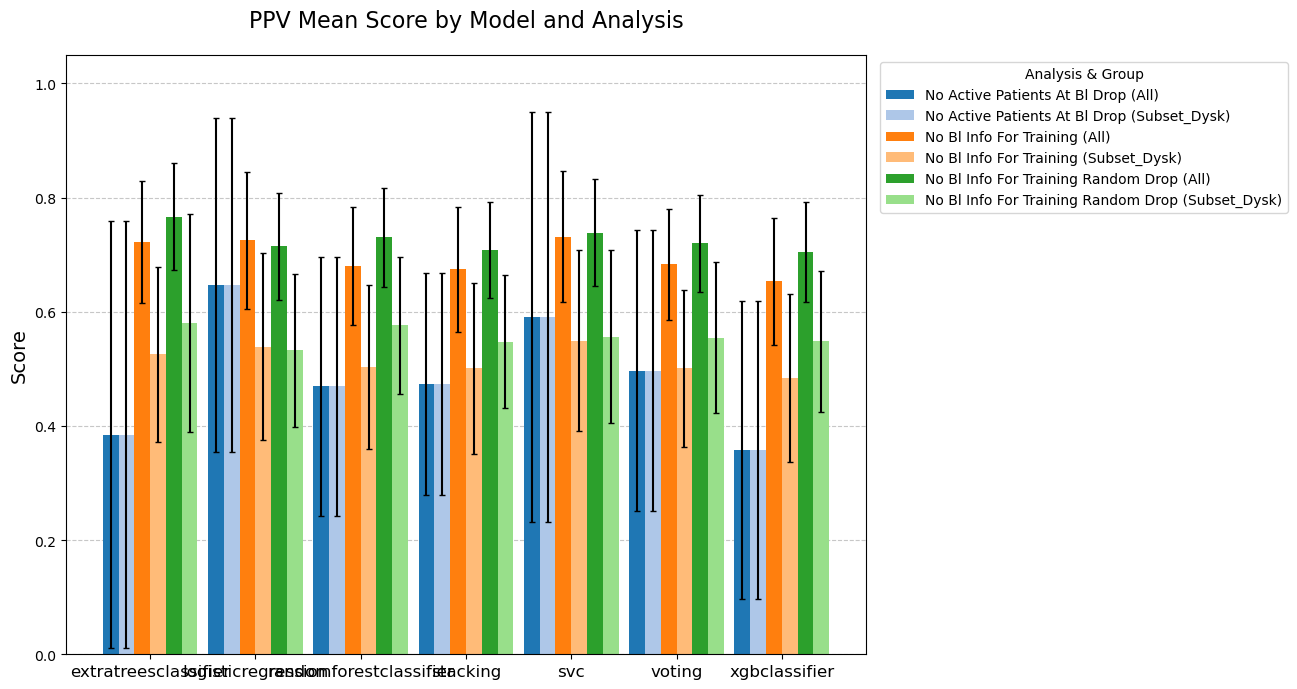

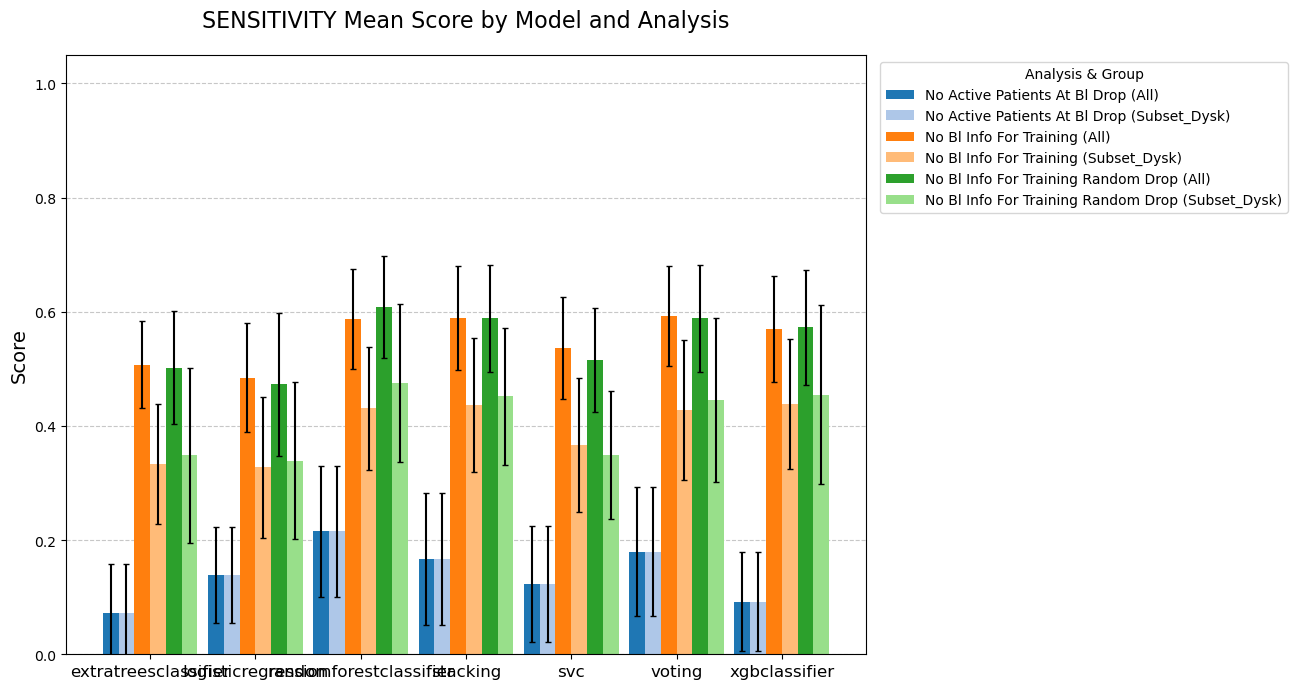

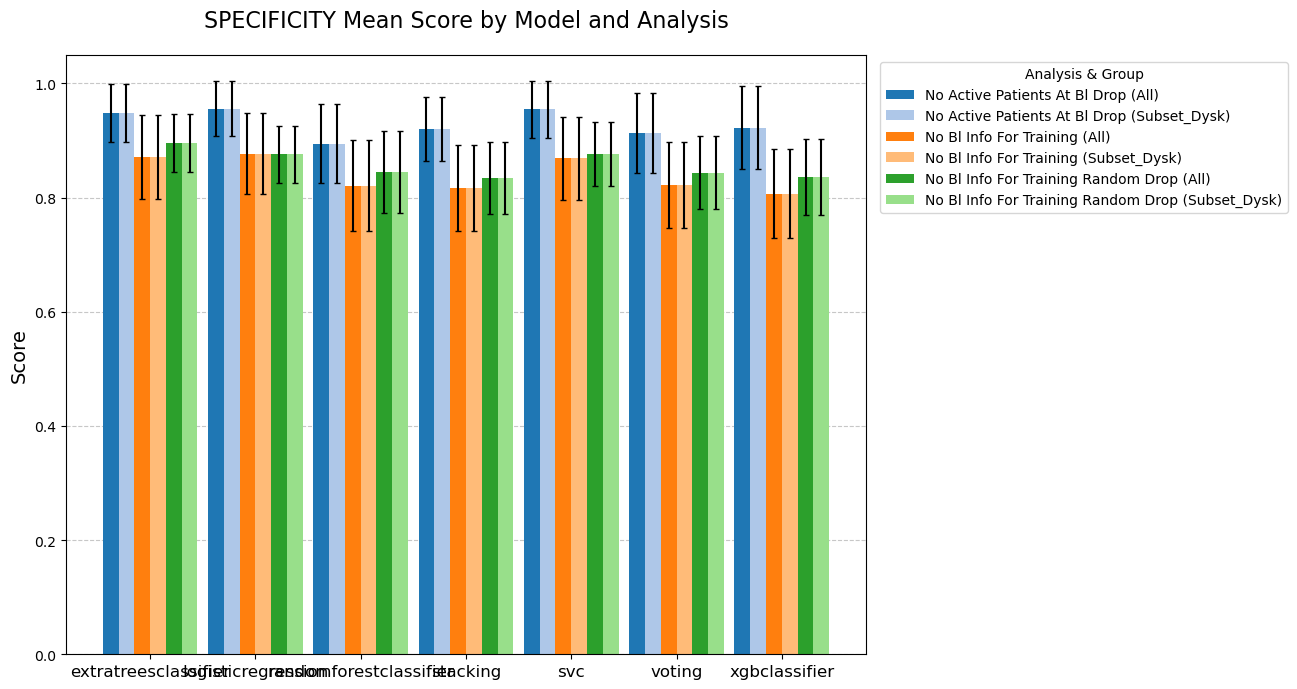

In [10]:
plot_full_summary(summary)

COLORBAR

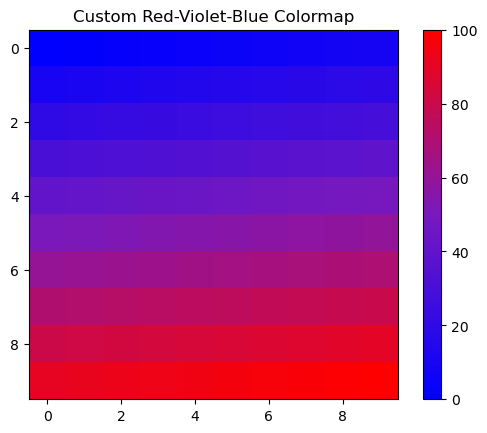

In [11]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Define colors in order: red, violet, blue
colors = ['blue', "#7919BE", 'red']

# Create custom colormap
custom_cmap = LinearSegmentedColormap.from_list('red_violet_blue', colors, N=512)

# Demonstrate the colormap
data = np.linspace(0, 100, 100).reshape(10, 10)
plt.imshow(data, cmap=custom_cmap)
plt.colorbar()
plt.title("Custom Red-Violet-Blue Colormap")
plt.show()

### LEDD for SVC

Load data

In [12]:
# Load shap raw values for LR and RF models
import pandas as pd
import numpy as np
import os

shap_data = '../results_w_calibration_v4/no_bl_info_for_training/FutureDyskinesia/svc/feature_analysis/shap_analysis/df_shap_data_filtered_calibrated.csv'
shap_vals = '../results_w_calibration_v4/no_bl_info_for_training/FutureDyskinesia/svc/feature_analysis/shap_analysis/df_shap_vals_filtered_calibrated.csv'
raw_proba = '../results_w_calibration_v4/no_bl_info_for_training/FutureDyskinesia/svc/raw_results.csv' # only to retrieve indices for run_id assignment, not used for metrics calculation

# load shap data and shap values
df_shap_data = pd.read_csv(shap_data, index_col=0)
df_shap_vals = pd.read_csv(shap_vals, index_col=0)
df_proba = pd.read_csv(raw_proba, index_col=0)
chunk_size = len(df_shap_data) // 30
df_proba_w_runid = add_run_id(df_proba, chunk_size=chunk_size)

SHAP Object

In [13]:
# create shap object
import shap
shap_values_obj = shap.Explanation(values=df_shap_vals.values, data=df_shap_data, 
									feature_names=df_shap_data.columns) # BASE VALUES kept as default..


raw_probabilities = df_proba['prob y=1'].values
run_ids = df_proba_w_runid['run_id'].values

x_plt = df_shap_data
x_plt = x_plt['ledd']
feature_to_plot = "ledd"

# load x 
x_neuro = pd.read_csv('../data/X_neuroart_v4.csv')

test_size = len(df_proba) // 30
train_size = len(x_neuro) - test_size

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
shap_values_obj

.values =
array([[ 0.05687052,  0.00955515,  0.00493315, ...,  0.03257597,
         0.00713764,  0.04324921],
       [ 0.02867089,  0.00651051, -0.02250315, ..., -0.02116473,
         0.00619249, -0.01690616],
       [ 0.03555604, -0.01274299, -0.00480093, ..., -0.01884443,
         0.00550244, -0.01493066],
       ...,
       [-0.01629993, -0.04004799, -0.00131697, ...,  0.02050463,
        -0.00259725, -0.0040233 ],
       [-0.11175161, -0.01545589, -0.00138808, ...,  0.02301696,
         0.00160161, -0.0042375 ],
       [-0.0162303 ,  0.016076  ,  0.00252555, ...,  0.02630146,
         0.00190905, -0.00461497]])

.data =
                MDS-UPDRS3_ON_total  LevodopaYears  AgonistiDopaminaYears  \
DisautonomyCat                                                              
0.0                            11.0            3.0                    3.0   
1.0                            15.0            3.0                    0.0   
0.0                            12.0            0.0          

Inverse transform LEDD

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Assuming these variables are defined:
# x_neuro: original DataFrame with 'ledd' column, indexed properly
# df_proba: DataFrame with indices and probabilities, sized to match chunks
# test_size: size of each chunk (e.g., 50)
# fitted_scalers: list that will hold scalers fitted on training chunks

# Fit scalers on training chunks (excluding test chunk indices)
fitted_scalers = []
for i in range(30):
    test_idx = df_proba.index[test_size*i : test_size*(i+1)]
    # Training set excludes test_idx
    x_neuro_train_curr = x_neuro.loc[~x_neuro.index.isin(test_idx)]
    
    # Fit scaler on this training chunk only (reshape needed for sklearn)
    scaler = StandardScaler()
    scaler.fit(x_neuro_train_curr['ledd'].values.reshape(-1, 1))
    fitted_scalers.append(scaler)

# Inverse transform "ledd" in chunks using the matching scaler
x_plt_final = []  # List to accumulate inverse transformed chunks

for i in range(30):
    # Slice the test chunk, reset index for alignment
    x_plt_curr = df_shap_data.iloc[test_size*i : test_size*(i+1)].copy()
    
    # Apply inverse transform with the corresponding scaler
    ledd_scaled = x_plt_curr['ledd'].values.reshape(-1, 1)
    ledd_unscaled = fitted_scalers[i].inverse_transform(ledd_scaled)
    
    # Replace column with unscaled values                                   !!!!! UNCOMMENT THIS LINE TO UPDATE THE PLOT DATAFRAME WITH UN-SCALED VALUES (for raw model plotting)
    #x_plt_curr['ledd'] = ledd_unscaled.flatten()
    
    # Check for out-of-range or suspicious values than original max 1600
    max_original_ledd = x_neuro['ledd'].max()
    max_transformed = np.max(ledd_unscaled)
    if max_transformed > max_original_ledd * 1.05:  # 5% tolerance
        print(f"Warning: Chunk {i} has max 'ledd' inverse transform {max_transformed} > original max {max_original_ledd}")
    
    # Append back original index for sorting later
    x_plt_final.append(x_plt_curr)

# Concatenate all chunks and restore original order by index
x_plt_final = pd.concat(x_plt_final, axis=0)



Official figure

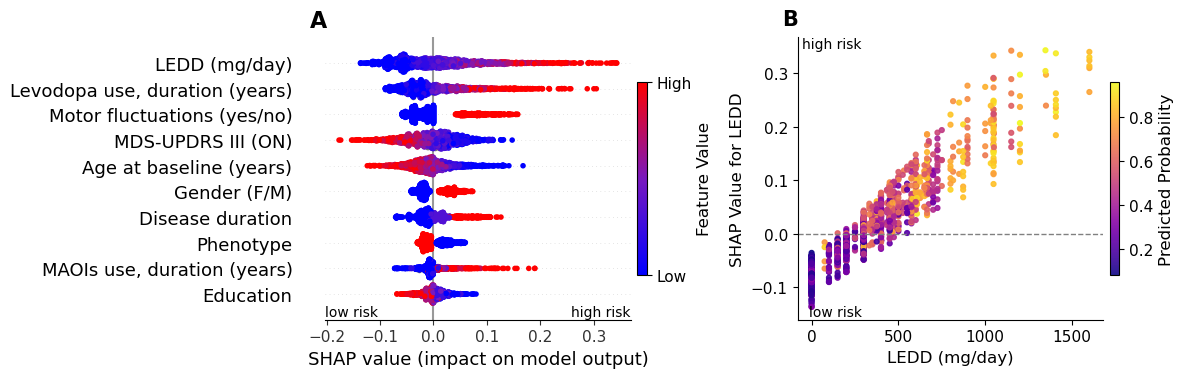

In [16]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
import numpy as np

# --- Set Global Font Properties ---
BASE_FONT_SIZE = 12
plt.rcParams.update({
    'font.size': BASE_FONT_SIZE,
    'axes.titlesize': BASE_FONT_SIZE + 2,
    'axes.labelsize': BASE_FONT_SIZE,
    'xtick.labelsize': BASE_FONT_SIZE - 1,
    'ytick.labelsize': BASE_FONT_SIZE - 1,
    'legend.fontsize': BASE_FONT_SIZE - 1,
    'figure.titlesize': BASE_FONT_SIZE + 4,
    'font.family': 'sans-serif'
})

# --- Define Colormap for PLOT 1 (Beeswarm) ---
colors = ['blue', "#7919BE", 'red']
custom_cmap = LinearSegmentedColormap.from_list('red_violet_blue', colors, N=512)

# --- 1. Create the Combined Figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4)) 
fig.set_facecolor('white') 

# --- 2. Plot 1: The *Real* SHAP Beeswarm Plot (on ax1) ---
# Patch the NoneType base_values with dummy zeros
if shap_values_obj.base_values is None:
    shap_values_obj.base_values = np.zeros(shap_values_obj.shape[0])

plt.sca(ax1) 
shap.summary_plot(
    shap_values_obj, 
    max_display=10, 
    show=False,
    cmap=custom_cmap,
    color_bar=False 
)

# --- 2.5 Rename Beeswarm Attributes ---
# # Map the original feature names to your new desired names
rename_map = {
    'ledd': 'LEDD (mg/day)',
    'LevodopaYears': 'Levodopa use, duration (years)',
    'MotorFluctuations': 'Motor fluctuations (yes/no)',
    'DiseaseYearsAtBL': 'Disease duration',
    'AgeBaseline': 'Age at baseline (years)',
    'MDS-UPDRS3_ON_total': 'MDS-UPDRS III (ON)',
    'AgonistiDopaminaYears': 'DA use, duration (years)',
    'LevodopaBinary': 'Use of Levodopa (Yes/No)',
    'Gender': 'Gender (F/M)',
    'IMAOYears': 'MAOIs use, duration (years)',
    'SleepWakeDisordersBinary': 'Sleep/Wake disorders (yes/no)',
    'Hyposmia': 'Hyposmia (yes/no)'

}

# Get the current labels that shap just set
current_labels = [label.get_text() for label in ax1.get_yticklabels()]

# Create the new list of labels
# .get(label, label) will use the new name if it's in your map, 
# otherwise it will keep the original name.
new_labels = [rename_map.get(label, label) for label in current_labels]

# Set the new, renamed labels on the plot
ax1.set_yticklabels(new_labels)

# --- 2.6 Reset Beeswarm Label Styles ---
# Force all y-tick labels on ax1 to be black and normal weight
base_font_color = 'black' 
for label in ax1.get_yticklabels():
    label.set_color(base_font_color)
    label.set_fontweight('normal')

# --- 3. Add *Our Own* Generic Colorbar for ax1 ---
generic_norm = Normalize(vmin=0, vmax=1)
sm = ScalarMappable(cmap=custom_cmap, norm=generic_norm)
sm.set_array([]) 
cbar1 = fig.colorbar(sm, ax=ax1, orientation='vertical', pad=0.02, fraction=0.03)
cbar1.set_label('Feature Value')
cbar1.set_ticks([0, 1])
cbar1.set_ticklabels(['Low', 'High'])

# --- 4. Plot 2: Custom Scatter Plot (on ax2) ---
scatter = ax2.scatter(
    x=x_plt_final['ledd'],                   
    y=shap_values_obj[:, feature_to_plot].values,   
    c=raw_probabilities,                           
    cmap='plasma', 
    alpha=0.9,
    s=12                                           
)
#ax2.set_title(f"SHAP Dependence Plot for LEDD")
ax2.axhline(0, color='grey', linestyle='--', linewidth=1)
ax2.set_xlabel(f"LEDD (mg/day)")
ax2.set_ylabel(f"SHAP Value for LEDD")
cbar2 = fig.colorbar(scatter, ax=ax2, label=f"Predicted Probability", pad=0.02, fraction=0.03)

# --- 5. Apply SHAP-like Style to *ax2* ---
shap_bg_color = "#FFFFFF"
ax2.set_facecolor(shap_bg_color)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- 6. Finalize and Save the Combined Figure ---
# Re-assert your desired figure size
fig.set_size_inches(12, 4) 


# --- 6.5 Add Low/High Risk Labels to ax1 (NEW SECTION) ---
# We use `transform=ax1.transAxes` to use relative coordinates (0 to 1)
# y=-0.1 places it just below the main x-axis label.
# 'ha' (horizontalalignment) anchors the text.
ax1.text(
    0.0, 0.05, 'low risk',
    transform=ax1.transAxes,
    ha='left',
    va='top',
    fontsize=BASE_FONT_SIZE - 2, # Make it slightly smaller
    color='black'
)

ax1.text(
    1.0, 0.05, 'high risk',
    transform=ax1.transAxes,
    ha='right',
    va='top',
    fontsize=BASE_FONT_SIZE - 2, # Make it slightly smaller
    color='black'
)

# --- Labels for ax2 (Y-axis) ---
ax2.text(
    0.21, 1.0, 'high risk',
    transform=ax2.transAxes,
    ha='right',
    va='top',
    fontsize=BASE_FONT_SIZE - 2,
    color='black'
)
ax2.text(
    0.21, 0.001, 'low risk',
    transform=ax2.transAxes,
    ha='right',
    va='bottom',
    fontsize=BASE_FONT_SIZE - 2,
    color='black'
)

# --- 6.6 Add Subplot Captions (A, B) (NEW SECTION) ---
# We use coordinates just outside the top-left corner of each axis.
ax1.text(
    -0.05, 1.1, 'A',
    transform=ax1.transAxes,
    ha='left',
    va='top',
    fontsize=BASE_FONT_SIZE + 4, # Make it a bit larger
    fontweight='bold',
    color='black'
)

ax2.text(
    -0.05, 1.1, 'B',
    transform=ax2.transAxes,
    ha='left',
    va='top',
    fontsize=BASE_FONT_SIZE + 3, # Make it a bit larger
    fontweight='bold',
    color='black'
)


# --- End of New Section ---
fig.tight_layout()
plt.savefig("./images/SVC_combined_official_shap_plot_renamed.svg", format='svg', bbox_inches='tight')
plt.show()

## explore Calibration

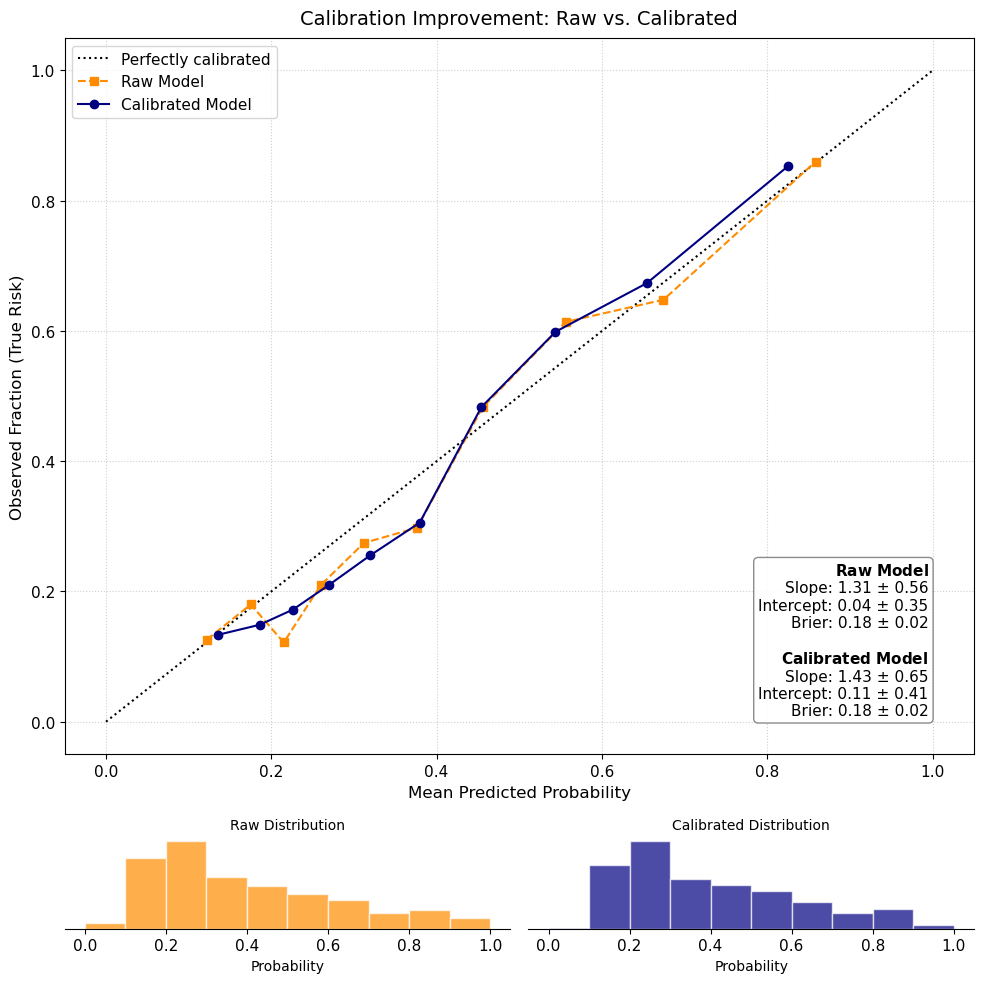

In [21]:
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay
import matplotlib.gridspec as gridspec

raw_res = pd.read_csv('../results_w_calibration_v4/no_bl_info_for_training/FutureDyskinesia/svc/raw_results_calibration.csv')


cal_metrics_raw = pd.read_csv('../results_w_calibration_v4/no_bl_info_for_training/FutureDyskinesia/svc/calibration_metrics_raw.csv')
cal_metrics_cal = pd.read_csv('../results_w_calibration_v4/no_bl_info_for_training/FutureDyskinesia/svc/calibration_metrics_calibrated.csv')

y_true_all = raw_res['real y'].values
y_probs_raw_all = raw_res['probs_raw'].values
y_probs_cal_all = raw_res['probs_cal'].values
X_test_all = raw_res['idx'].values

raw_stats = {
'slope': (cal_metrics_raw['calib_slope'].mean(), cal_metrics_raw['calib_slope'].std()),
'intercept': (cal_metrics_raw['calib_intercept'].mean(), cal_metrics_raw['calib_intercept'].std()),
'brier': (cal_metrics_raw['brier_score'].mean(), cal_metrics_raw['brier_score'].std())
}

cal_stats = {
'slope': (cal_metrics_cal['calib_slope'].mean(), cal_metrics_cal['calib_slope'].std()),
'intercept': (cal_metrics_cal['calib_intercept'].mean(), cal_metrics_cal['calib_intercept'].std()),
    'brier': (cal_metrics_cal['brier_score'].mean(), cal_metrics_cal['brier_score'].std())
}



# Call the function
plot_professional_calibration(
    y_true_all,      # Your flattened list of true labels
    y_probs_raw_all, # Your flattened list of raw probs
    y_probs_cal_all, # Your flattened list of calibrated probs
    raw_stats, 
    cal_stats
)

## LEDD FOR XGB

Load data

In [22]:
# Load shap raw values for LR and RF models
import pandas as pd
import numpy as np
import os

shap_data = '../results_w_calibration_v4/no_bl_info_for_training/FutureDyskinesia/xgbclassifier/feature_analysis/shap_analysis/df_shap_data_filtered_calibrated.csv'
shap_vals = '../results_w_calibration_v4/no_bl_info_for_training/FutureDyskinesia/xgbclassifier/feature_analysis/shap_analysis/df_shap_vals_filtered_calibrated.csv'
raw_proba = '../results_w_calibration_v4/no_bl_info_for_training/FutureDyskinesia/xgbclassifier/raw_results.csv'

# load shap data and shap values
df_shap_data = pd.read_csv(shap_data, index_col=0)
df_shap_vals = pd.read_csv(shap_vals, index_col=0)
df_proba = pd.read_csv(raw_proba, index_col=0)

chunk_size = len(df_shap_data) // 30  # n. of external iterations..
df_proba_w_runid = add_run_id(df_proba, chunk_size=chunk_size)

SHAP Object

In [23]:
# create shap object
from curses import raw
import shap
shap_values_obj = shap.Explanation(values=df_shap_vals.values, data=df_shap_data, 
									feature_names=df_shap_data.columns) # BASE VALUES kept as default..


raw_probabilities = df_proba['prob y=1'].values
run_ids = df_proba_w_runid['run_id'].values

x_plt = df_shap_data
x_plt = x_plt['ledd']
feature_to_plot = "ledd"

# load x 
x_neuro = pd.read_csv('../data/X_neuroart_v4.csv')

test_size = len(df_proba) // 30
train_size = len(x_neuro) - test_size

Inverse transform LEDD

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Assuming these variables are defined:
# x_neuro: original DataFrame with 'ledd' column, indexed properly
# df_proba: DataFrame with indices and probabilities, sized to match chunks
# test_size: size of each chunk (e.g., 50)
# fitted_scalers: list that will hold scalers fitted on training chunks

# Fit scalers on training chunks (excluding test chunk indices)
fitted_scalers = []
for i in range(30):
    test_idx = df_proba.index[test_size*i : test_size*(i+1)]
    # Training set excludes test_idx
    x_neuro_train_curr = x_neuro.loc[~x_neuro.index.isin(test_idx)]
    
    # Fit scaler on this training chunk only (reshape needed for sklearn)
    scaler = StandardScaler()
    scaler.fit(x_neuro_train_curr['ledd'].values.reshape(-1, 1))
    fitted_scalers.append(scaler)

# Inverse transform "ledd" in chunks using the matching scaler
x_plt_final = []  # List to accumulate inverse transformed chunks

for i in range(30):
    # Slice the test chunk, reset index for alignment
    x_plt_curr = df_shap_data.iloc[test_size*i : test_size*(i+1)].copy()
    
    # Apply inverse transform with the corresponding scaler
    ledd_scaled = x_plt_curr['ledd'].values.reshape(-1, 1)
    ledd_unscaled = fitted_scalers[i].inverse_transform(ledd_scaled)
    
    # Replace column with unscaled values
    #x_plt_curr['ledd'] = ledd_unscaled.flatten()
    
    # Check for out-of-range or suspicious values than original max 1600
    max_original_ledd = x_neuro['ledd'].max()
    max_transformed = np.max(ledd_unscaled)
    if max_transformed > max_original_ledd * 1.05:  # 5% tolerance
        print(f"Warning: Chunk {i} has max 'ledd' inverse transform {max_transformed} > original max {max_original_ledd}")
    
    # Append back original index for sorting later
    x_plt_final.append(x_plt_curr)

# Concatenate all chunks and restore original order by index
x_plt_final = pd.concat(x_plt_final, axis=0)



Official Figure

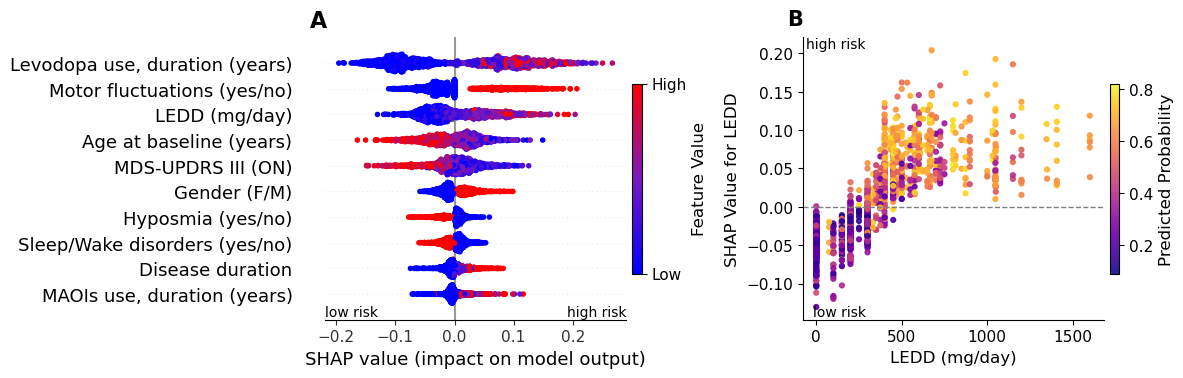

In [25]:
import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
import numpy as np
import shap

# --- Set Global Font Properties ---
BASE_FONT_SIZE = 12
plt.rcParams.update({
    'font.size': BASE_FONT_SIZE,
    'axes.titlesize': BASE_FONT_SIZE + 2,
    'axes.labelsize': BASE_FONT_SIZE,
    'xtick.labelsize': BASE_FONT_SIZE - 1,
    'ytick.labelsize': BASE_FONT_SIZE - 1,
    'legend.fontsize': BASE_FONT_SIZE - 1,
    'figure.titlesize': BASE_FONT_SIZE + 4,
    'font.family': 'sans-serif'
})

# --- Define Colormap for PLOT 1 (Beeswarm) ---
colors = ['blue', "#7919BE", 'red']
custom_cmap = LinearSegmentedColormap.from_list('red_violet_blue', colors, N=512)

# --- 1. Create the Combined Figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4)) 
fig.set_facecolor('white') 

# Patch the NoneType base_values with dummy zeros
if shap_values_obj.base_values is None:
    shap_values_obj.base_values = np.zeros(shap_values_obj.shape[0])

# --- 2. Plot 1: The *Real* SHAP Beeswarm Plot (on ax1) ---
plt.sca(ax1) 
shap.summary_plot(
    shap_values_obj, 
    max_display=10, 
    show=False,
    cmap=custom_cmap,
    color_bar=False 
)

# --- 2.5 Rename Beeswarm Attributes ---
# # Map the original feature names to your new desired names
rename_map = {
    'ledd': 'LEDD (mg/day)',
    'LevodopaYears': 'Levodopa use, duration (years)',
    'MotorFluctuations': 'Motor fluctuations (yes/no)',
    'DiseaseYearsAtBL': 'Disease duration',
    'AgeBaseline': 'Age at baseline (years)',
    'MDS-UPDRS3_ON_total': 'MDS-UPDRS III (ON)',
    'AgonistiDopaminaYears': 'DA use, duration (years)',
    'LevodopaBinary': 'Use of Levodopa (Yes/No)',
    'Gender': 'Gender (F/M)',
    'IMAOYears': 'MAOIs use, duration (years)',
    'SleepWakeDisordersBinary': 'Sleep/Wake disorders (yes/no)',
    'Hyposmia': 'Hyposmia (yes/no)'
}

# Get the current labels that shap just set
current_labels = [label.get_text() for label in ax1.get_yticklabels()]

# Create the new list of labels
# .get(label, label) will use the new name if it's in your map, 
# otherwise it will keep the original name.
new_labels = [rename_map.get(label, label) for label in current_labels]

# Set the new, renamed labels on the plot
ax1.set_yticklabels(new_labels)

# --- 2.6 Reset Beeswarm Label Styles ---
# Force all y-tick labels on ax1 to be black and normal weight
base_font_color = 'black' 
for label in ax1.get_yticklabels():
    label.set_color(base_font_color)
    label.set_fontweight('normal')

# --- 3. Add *Our Own* Generic Colorbar for ax1 ---
generic_norm = Normalize(vmin=0, vmax=1)
sm = ScalarMappable(cmap=custom_cmap, norm=generic_norm)
sm.set_array([]) 
cbar1 = fig.colorbar(sm, ax=ax1, orientation='vertical', pad=0.02, fraction=0.03)
cbar1.set_label('Feature Value')
cbar1.set_ticks([0, 1])
cbar1.set_ticklabels(['Low', 'High'])

# --- 4. Plot 2: Custom Scatter Plot (on ax2) ---
scatter = ax2.scatter(
    x=x_plt_final['ledd'],                   
    y=shap_values_obj[:, feature_to_plot].values,   
    c=raw_probabilities,                           
    cmap='plasma', 
    alpha=0.9,
    s=12                                           
)
#ax2.set_title(f"SHAP Dependence Plot for LEDD")
ax2.axhline(0, color='grey', linestyle='--', linewidth=1)
ax2.set_xlabel(f"LEDD (mg/day)")
ax2.set_ylabel(f"SHAP Value for LEDD")
cbar2 = fig.colorbar(scatter, ax=ax2, label=f"Predicted Probability", pad=0.02, fraction=0.03)

# --- 5. Apply SHAP-like Style to *ax2* ---
shap_bg_color = "#FFFFFF"
ax2.set_facecolor(shap_bg_color)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- 6. Finalize and Save the Combined Figure ---
# Re-assert your desired figure size
fig.set_size_inches(12, 4) 


# --- 6.5 Add Low/High Risk Labels to ax1 (NEW SECTION) ---
# We use `transform=ax1.transAxes` to use relative coordinates (0 to 1)
# y=-0.1 places it just below the main x-axis label.
# 'ha' (horizontalalignment) anchors the text.
ax1.text(
    0.0, 0.05, 'low risk',
    transform=ax1.transAxes,
    ha='left',
    va='top',
    fontsize=BASE_FONT_SIZE - 2, # Make it slightly smaller
    color='black'
)

ax1.text(
    1.0, 0.05, 'high risk',
    transform=ax1.transAxes,
    ha='right',
    va='top',
    fontsize=BASE_FONT_SIZE - 2, # Make it slightly smaller
    color='black'
)

# --- Labels for ax2 (Y-axis) ---
ax2.text(
    0.21, 1.0, 'high risk',
    transform=ax2.transAxes,
    ha='right',
    va='top',
    fontsize=BASE_FONT_SIZE - 2,
    color='black'
)
ax2.text(
    0.21, 0.001, 'low risk',
    transform=ax2.transAxes,
    ha='right',
    va='bottom',
    fontsize=BASE_FONT_SIZE - 2,
    color='black'
)

# --- 6.6 Add Subplot Captions (A, B) (NEW SECTION) ---
# We use coordinates just outside the top-left corner of each axis.
ax1.text(
    -0.05, 1.1, 'A',
    transform=ax1.transAxes,
    ha='left',
    va='top',
    fontsize=BASE_FONT_SIZE + 4, # Make it a bit larger
    fontweight='bold',
    color='black'
)

ax2.text(
    -0.05, 1.1, 'B',
    transform=ax2.transAxes,
    ha='left',
    va='top',
    fontsize=BASE_FONT_SIZE + 3, # Make it a bit larger
    fontweight='bold',
    color='black'
)


# --- End of New Section ---
fig.tight_layout()
plt.savefig("./images/XGB_combined_official_shap_plot_renamed.svg", format='svg', bbox_inches='tight')
plt.show()

## Explore calibration for XGB

In [27]:
raw_res = pd.read_csv('../results_w_calibration_v4/no_bl_info_for_training/FutureDyskinesia/xgbclassifier/raw_results_calibration.csv')
cal_metrics_raw = pd.read_csv('../results_w_calibration_v4/no_bl_info_for_training/FutureDyskinesia/xgbclassifier/calibration_metrics_raw.csv')
cal_metrics_cal = pd.read_csv('../results_w_calibration_v4/no_bl_info_for_training/FutureDyskinesia/xgbclassifier/calibration_metrics_calibrated.csv')

y_true_all_B = raw_res['real y'].values
y_probs_raw_all_B = raw_res['probs_raw'].values
y_probs_cal_all_B = raw_res['probs_cal'].values
X_test_all_B = raw_res['idx'].values

raw_stats_B = {
'slope': (cal_metrics_raw['calib_slope'].mean(), cal_metrics_raw['calib_slope'].std()),
'intercept': (cal_metrics_raw['calib_intercept'].mean(), cal_metrics_raw['calib_intercept'].std()),
'brier': (cal_metrics_raw['brier_score'].mean(), cal_metrics_raw['brier_score'].std())
}

cal_stats_B = {
'slope': (cal_metrics_cal['calib_slope'].mean(), cal_metrics_cal['calib_slope'].std()),
'intercept': (cal_metrics_cal['calib_intercept'].mean(), cal_metrics_cal['calib_intercept'].std()),
    'brier': (cal_metrics_cal['brier_score'].mean(), cal_metrics_cal['brier_score'].std())
}

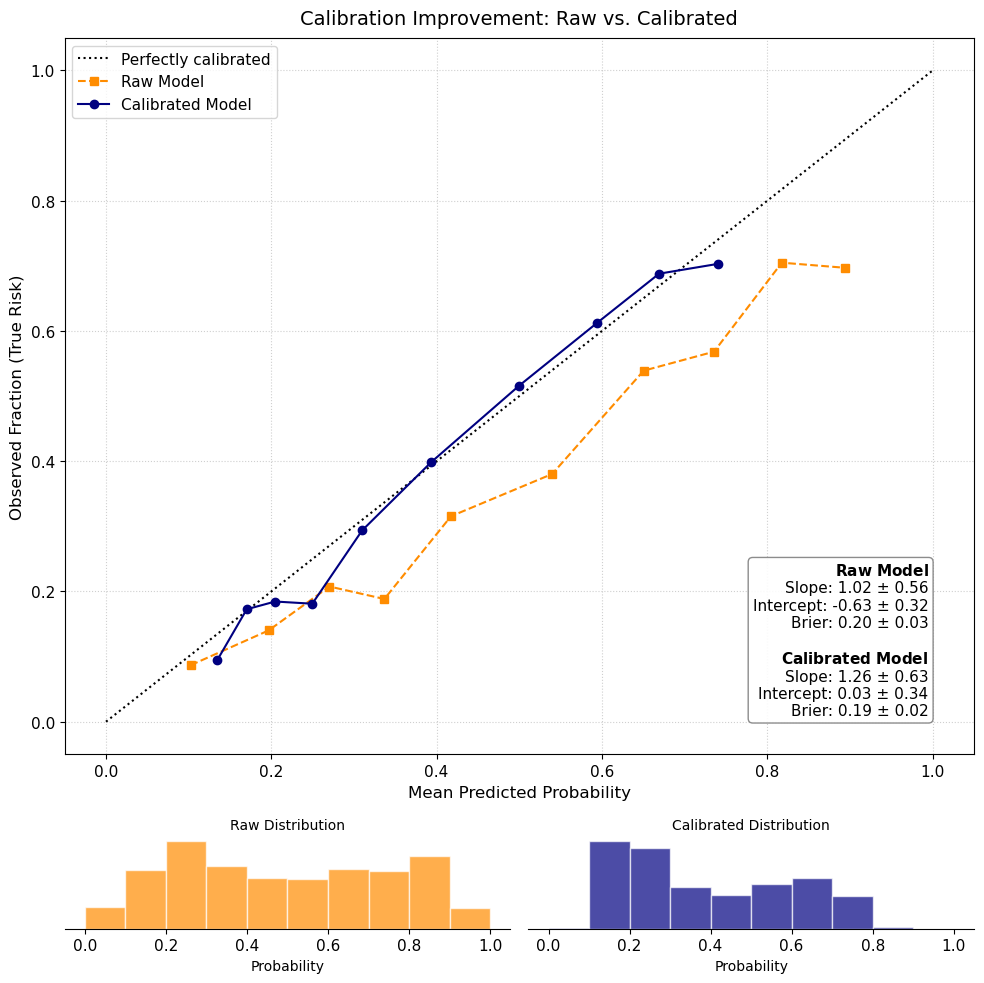

In [28]:




# Call the function
plot_professional_calibration(
    y_true_all_B,      # Your flattened list of true labels
    y_probs_raw_all_B, # Your flattened list of raw probs
    y_probs_cal_all_B, # Your flattened list of calibrated probs
    raw_stats_B, 
    cal_stats_B
)

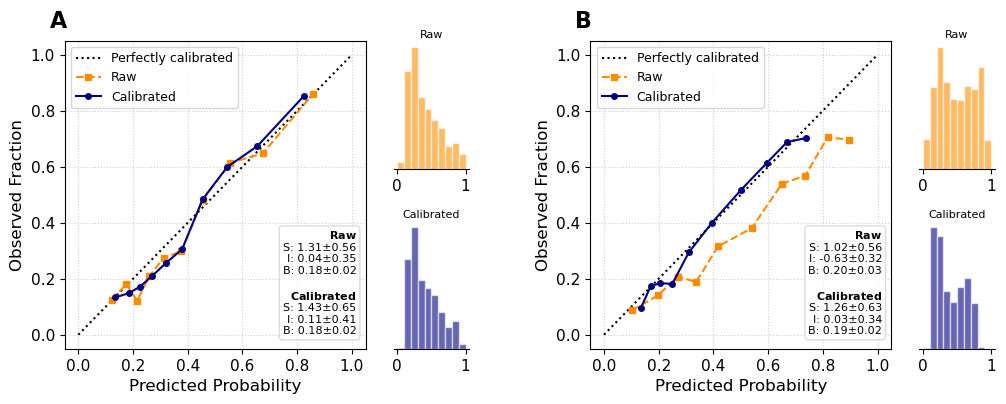

In [29]:
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay
import matplotlib.gridspec as gridspec
import numpy as np

# --- Set Global Font Properties (Matches your SHAP code) ---
BASE_FONT_SIZE = 12
plt.rcParams.update({
    'font.size': BASE_FONT_SIZE,
    'axes.titlesize': BASE_FONT_SIZE + 2,
    'axes.labelsize': BASE_FONT_SIZE,
    'xtick.labelsize': BASE_FONT_SIZE - 1,
    'ytick.labelsize': BASE_FONT_SIZE - 1,
    'legend.fontsize': BASE_FONT_SIZE - 1,
    'figure.titlesize': BASE_FONT_SIZE + 4,
    'font.family': 'sans-serif',
    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.alpha': 0.6
})

def plot_dual_professional_calibration(
    data_left,  # Dict: {'y_true', 'p_raw', 'p_cal', 'raw_m', 'cal_m', 'title'}
    data_right, # Dict: {'y_true', 'p_raw', 'p_cal', 'raw_m', 'cal_m', 'title'}
    save_path=None
):
    """
    Generates two side-by-side calibration plots.
    Size: 12x4 (Matches SHAP combined figure dimensions)
    Includes A/B Subplot Captions.
    """
    # Create figure with your specific dimensions
    fig = plt.figure(figsize=(12, 4))
    fig.set_facecolor('white')
    
    # Divide the 12x4 space into two main halves
    outer_gs = gridspec.GridSpec(1, 2, wspace=0.3)

    def draw_sub_plot(gs_spec, data, letter):
        # Internal layout: Main plot on left, histograms stacked on right
        # This prevents vertical overlap with x-ticks in a short (4-inch) figure
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            2, 2, 
            subplot_spec=gs_spec, 
            width_ratios=[4, 1], 
            wspace=0.15, hspace=0.4
        )
        
        ax_main = plt.subplot(inner_gs[:, 0])
        ax_h1 = plt.subplot(inner_gs[0, 1])
        ax_h2 = plt.subplot(inner_gs[1, 1])

        # 1. Main Calibration Curves
        CalibrationDisplay.from_predictions(
            data['y_true'], data['p_raw'], n_bins=10, name="Raw",
            ax=ax_main, color="darkorange", strategy='quantile', marker='s', linestyle='--', markersize=4
        )
        CalibrationDisplay.from_predictions(
            data['y_true'], data['p_cal'], n_bins=10, name="Calibrated",
            ax=ax_main, strategy='quantile', color="navy", marker='o', markersize=4
        )

        ax_main.set_title(data.get('title', 'Calibration'), pad=10)
        ax_main.set_xlabel("Predicted Probability")
        ax_main.set_ylabel("Observed Fraction")
        ax_main.legend(loc='upper left', frameon=True, fontsize=BASE_FONT_SIZE-3)

        # 2. Scorecard (Metrics Box)
        def fmt(m, key):
            mean, std = m[key]
            return f"{mean:.2f}±{std:.2f}"

        stats_text = (
            r"$\bf{Raw}$" + "\n"
            f"S: {fmt(data['raw_m'], 'slope')}\n"
            f"I: {fmt(data['raw_m'], 'intercept')}\n"
            f"B: {fmt(data['raw_m'], 'brier')}\n\n"
            r"$\bf{Calibrated}$" + "\n"
            f"S: {fmt(data['cal_m'], 'slope')}\n"
            f"I: {fmt(data['cal_m'], 'intercept')}\n"
            f"B: {fmt(data['cal_m'], 'brier')}"
        )
        
        props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='lightgray')
        ax_main.text(0.97, 0.04, stats_text, transform=ax_main.transAxes, 
                     fontsize=BASE_FONT_SIZE-4, verticalalignment='bottom', 
                     horizontalalignment='right', bbox=props)

        # 3. Histograms (Side-stacked)
        for ax, probs, title, c in [
            (ax_h1, data['p_raw'], "Raw", "darkorange"), 
            (ax_h2, data['p_cal'], "Calibrated", "navy")
        ]:
            ax.hist(probs, range=(0, 1), bins=10, color=c, alpha=0.6, edgecolor='white')
            ax.set_title(title, fontsize=BASE_FONT_SIZE-4, pad=2)
            ax.set_xticks([0, 1])
            ax.set_yticks([])
            ax.grid(False)
            for s in ['top', 'right', 'left']:
                ax.spines[s].set_visible(False)

        # 4. Add Subplot Captions (A, B) using your exact coordinate logic
        ax_main.text(
            -0.05, 1.1, letter,
            transform=ax_main.transAxes,
            ha='left', va='top',
            fontsize=BASE_FONT_SIZE + 4,
            fontweight='bold',
            color='black'
        )

    # Execute drawing
    draw_sub_plot(outer_gs[0], data_left, 'A')
    draw_sub_plot(outer_gs[1], data_right, 'B')

    if save_path:
        plt.savefig(save_path, format='svg', bbox_inches='tight')
    plt.show()


dataset_a = {'y_true': y_true_all, 'p_raw': y_probs_raw_all, 'p_cal': y_probs_cal_all, 'raw_m': raw_stats, 'cal_m': cal_stats, 'title': ''} #SVC
dataset_b = {'y_true': y_true_all_B, 'p_raw': y_probs_raw_all_B, 'p_cal': y_probs_cal_all_B, 'raw_m': raw_stats_B, 'cal_m': cal_stats_B, 'title': ''} #XGB
# --- Call with your data ---
plot_dual_professional_calibration(dataset_a, dataset_b, save_path="./images/dual_calibration_plot_dyskinesia.svg")

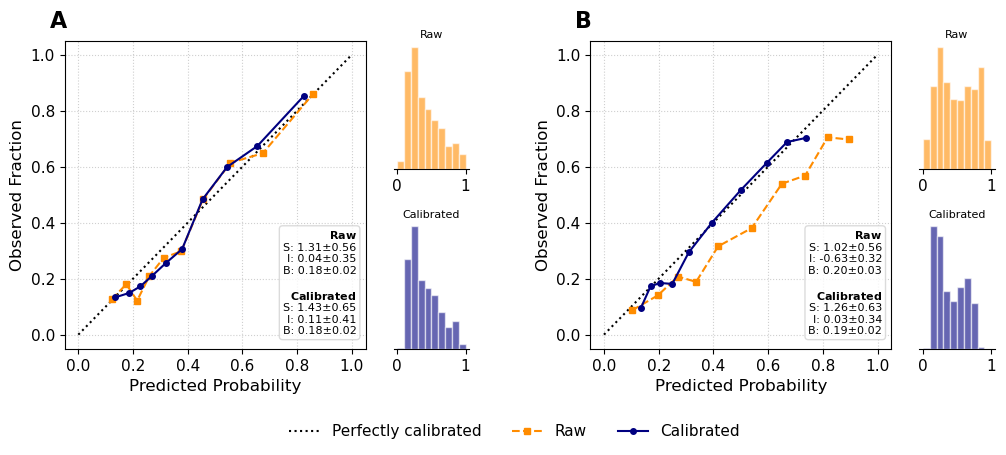

In [32]:
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay
import matplotlib.gridspec as gridspec
import numpy as np

# --- Set Global Font Properties ---
BASE_FONT_SIZE = 12
plt.rcParams.update({
    'font.size': BASE_FONT_SIZE,
    'axes.titlesize': BASE_FONT_SIZE + 2,
    'axes.labelsize': BASE_FONT_SIZE,
    'xtick.labelsize': BASE_FONT_SIZE - 1,
    'ytick.labelsize': BASE_FONT_SIZE - 1,
    'legend.fontsize': BASE_FONT_SIZE - 1,
    'figure.titlesize': BASE_FONT_SIZE + 4,
    'font.family': 'sans-serif',
    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.alpha': 0.6
})

def plot_dual_professional_calibration(
    data_left,  
    data_right, 
    save_path=None
):
    fig = plt.figure(figsize=(12, 4))
    fig.set_facecolor('white')
    
    outer_gs = gridspec.GridSpec(1, 2, wspace=0.3)

    def draw_sub_plot(gs_spec, data, letter):
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            2, 2, 
            subplot_spec=gs_spec, 
            width_ratios=[4, 1], 
            wspace=0.15, hspace=0.4
        )
        
        ax_main = plt.subplot(inner_gs[:, 0])
        ax_h1 = plt.subplot(inner_gs[0, 1])
        ax_h2 = plt.subplot(inner_gs[1, 1])

        # 1. Main Calibration Curves
        CalibrationDisplay.from_predictions(
            data['y_true'], data['p_raw'], n_bins=10, name="Raw",
            ax=ax_main, color="darkorange", strategy='quantile', marker='s', linestyle='--', markersize=4
        )
        CalibrationDisplay.from_predictions(
            data['y_true'], data['p_cal'], n_bins=10, name="Calibrated",
            ax=ax_main, strategy='quantile', color="navy", marker='o', markersize=4
        )

        # --- FIX: Forcefully remove scikit-learn's auto-generated legend ---
        if ax_main.get_legend() is not None:
            ax_main.get_legend().remove()

        ax_main.set_title(data.get('title', 'Calibration'), pad=10)
        ax_main.set_xlabel("Predicted Probability")
        ax_main.set_ylabel("Observed Fraction")

        # 2. Scorecard (Metrics Box)
        def fmt(m, key):
            mean, std = m[key]
            return f"{mean:.2f}±{std:.2f}"

        stats_text = (
            r"$\bf{Raw}$" + "\n"
            f"S: {fmt(data['raw_m'], 'slope')}\n"
            f"I: {fmt(data['raw_m'], 'intercept')}\n"
            f"B: {fmt(data['raw_m'], 'brier')}\n\n"
            r"$\bf{Calibrated}$" + "\n"
            f"S: {fmt(data['cal_m'], 'slope')}\n"
            f"I: {fmt(data['cal_m'], 'intercept')}\n"
            f"B: {fmt(data['cal_m'], 'brier')}"
        )
        
        props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='lightgray')
        ax_main.text(0.97, 0.04, stats_text, transform=ax_main.transAxes, 
                     fontsize=BASE_FONT_SIZE-4, verticalalignment='bottom', 
                     horizontalalignment='right', bbox=props)

        # 3. Histograms (Side-stacked)
        for ax, probs, title, c in [
            (ax_h1, data['p_raw'], "Raw", "darkorange"), 
            (ax_h2, data['p_cal'], "Calibrated", "navy")
        ]:
            ax.hist(probs, range=(0, 1), bins=10, color=c, alpha=0.6, edgecolor='white')
            ax.set_title(title, fontsize=BASE_FONT_SIZE-4, pad=2)
            ax.set_xticks([0, 1])
            ax.set_yticks([])
            ax.grid(False)
            for s in ['top', 'right', 'left']:
                ax.spines[s].set_visible(False)

        # 4. Add Subplot Captions (A, B)
        ax_main.text(
            -0.05, 1.1, letter,
            transform=ax_main.transAxes,
            ha='left', va='top',
            fontsize=BASE_FONT_SIZE + 4,
            fontweight='bold',
            color='black'
        )
        
        return ax_main

    # Execute drawing and capture the left axis
    ax_A = draw_sub_plot(outer_gs[0], data_left, 'A')
    draw_sub_plot(outer_gs[1], data_right, 'B')

    # --- Global Centered Legend ---
    handles, labels = ax_A.get_legend_handles_labels()
    
    unique_labels = []
    unique_handles = []
    for handle, label in zip(handles, labels):
        if label not in unique_labels:
            unique_labels.append(label)
            unique_handles.append(handle)

    fig.legend(
        unique_handles, unique_labels, 
        loc='lower center', 
        bbox_to_anchor=(0.5, -0.15),  
        ncol=len(unique_labels),      
        frameon=False,
        fontsize=BASE_FONT_SIZE - 1
    )

    if save_path:
        plt.savefig(save_path, format='svg', bbox_inches='tight')
    plt.show()


dataset_a = {'y_true': y_true_all, 'p_raw': y_probs_raw_all, 'p_cal': y_probs_cal_all, 'raw_m': raw_stats, 'cal_m': cal_stats, 'title': ''} #SVC
dataset_b = {'y_true': y_true_all_B, 'p_raw': y_probs_raw_all_B, 'p_cal': y_probs_cal_all_B, 'raw_m': raw_stats_B, 'cal_m': cal_stats_B, 'title': ''} #XGB
# --- Call with your data ---
plot_dual_professional_calibration(dataset_a, dataset_b, save_path="./images/dual_calibration_plot_dyskinesia.svg")